# ML - TIME SERIES FORECASTING

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from utils1 import test_stationarity
from pmdarima import auto_arima
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
# Versiones compatibles
print(np.__version__)
print(pmdarima.__version__)

1.26.4
2.0.3


# Paso 1: Carga del conjunto de datos
[fuente](https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv)

In [6]:
df = pd.read_csv('../data/raw/sales.csv')
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


# Paso 2: Realizamos un breve EDA 

In [7]:
df.shape

(366, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


In [9]:
df.nunique()

date     366
sales    366
dtype: int64

In [10]:
df.duplicated().sum()

0

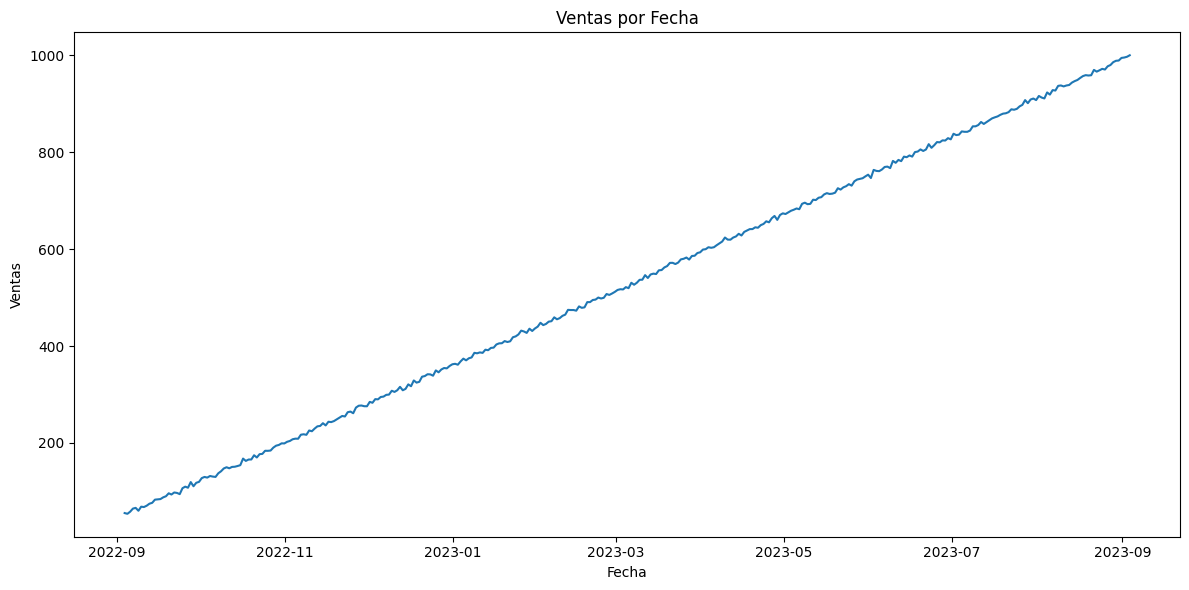

In [11]:
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='sales')

plt.title('Ventas por Fecha')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.tight_layout()

<Axes: ylabel='sales'>

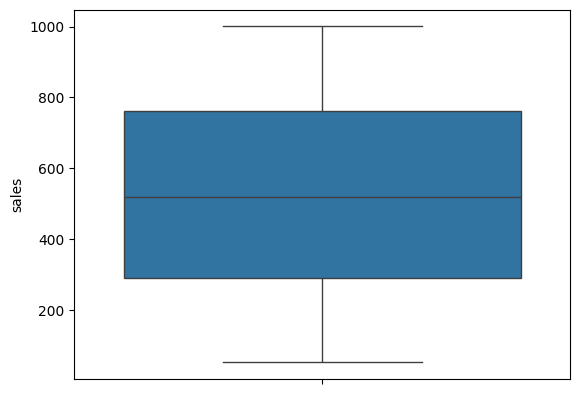

In [7]:
sns.boxplot(data=df, y="sales")

<Axes: ylabel='date'>

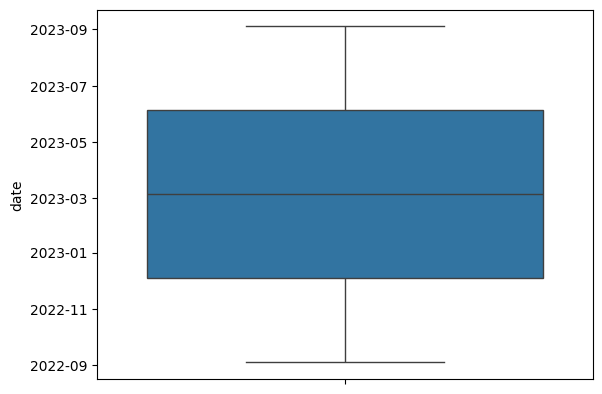

In [8]:
sns.boxplot(data=df, y="date")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    366 non-null    datetime64[ns]
 1   sales   366 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB


> ## Observaciones:
>
> - Existen un total de 366 filas (días) y 2 columnas. Por lo que los datos representan el numero de ventas a lo largo de un año
> - La variable date es tipo objeto por lo que la pasamos a formato fecha(datetime) para poder trabajar con ella, la variable sales es de tipo flotante
> - No tenemos datos faltantes, duplicados ni outliers
> - En el gráfico podemos observar que las ventas tienden a crecer a lo largo del tiempo

# Paso 3: Construimos y analizamos la serie temporal


In [12]:
# Convertimos al formato año-mes-día (descarta la hora)
df['date'] = df['date'].dt.date  # esto la convierte a tipo "date" (no datetime)

# Establecemos la columna 'date' como índice
df.set_index('date', inplace=True)

df

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633
...,...
2023-08-30,989.600354
2023-08-31,994.987326
2023-09-01,995.814415


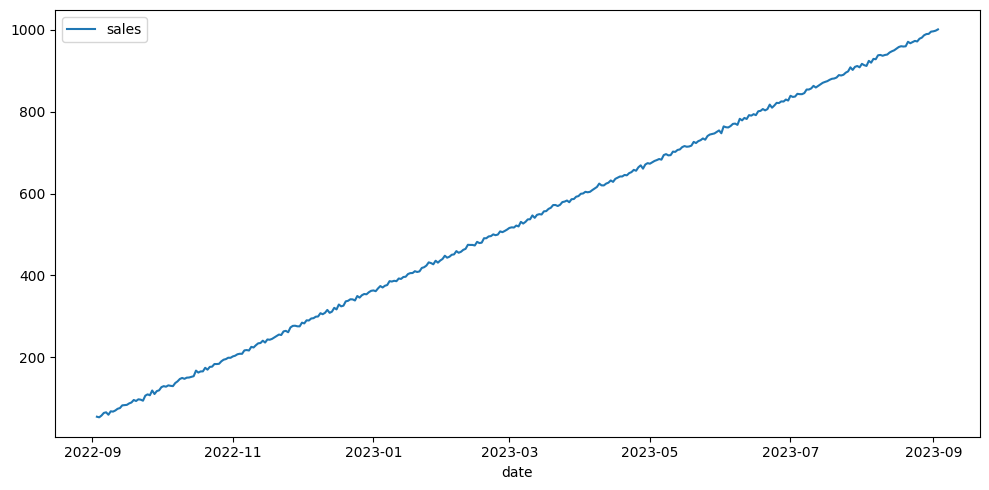

In [13]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)

plt.tight_layout()

## ¿Cuál es el tensor de la serie temporal? 
### La unidad de tiempo mínimo para la cual hay datos es día

## ¿Cuál es la tendencia?

In [14]:
decomposition = seasonal_decompose(df, period=7)
decomposition

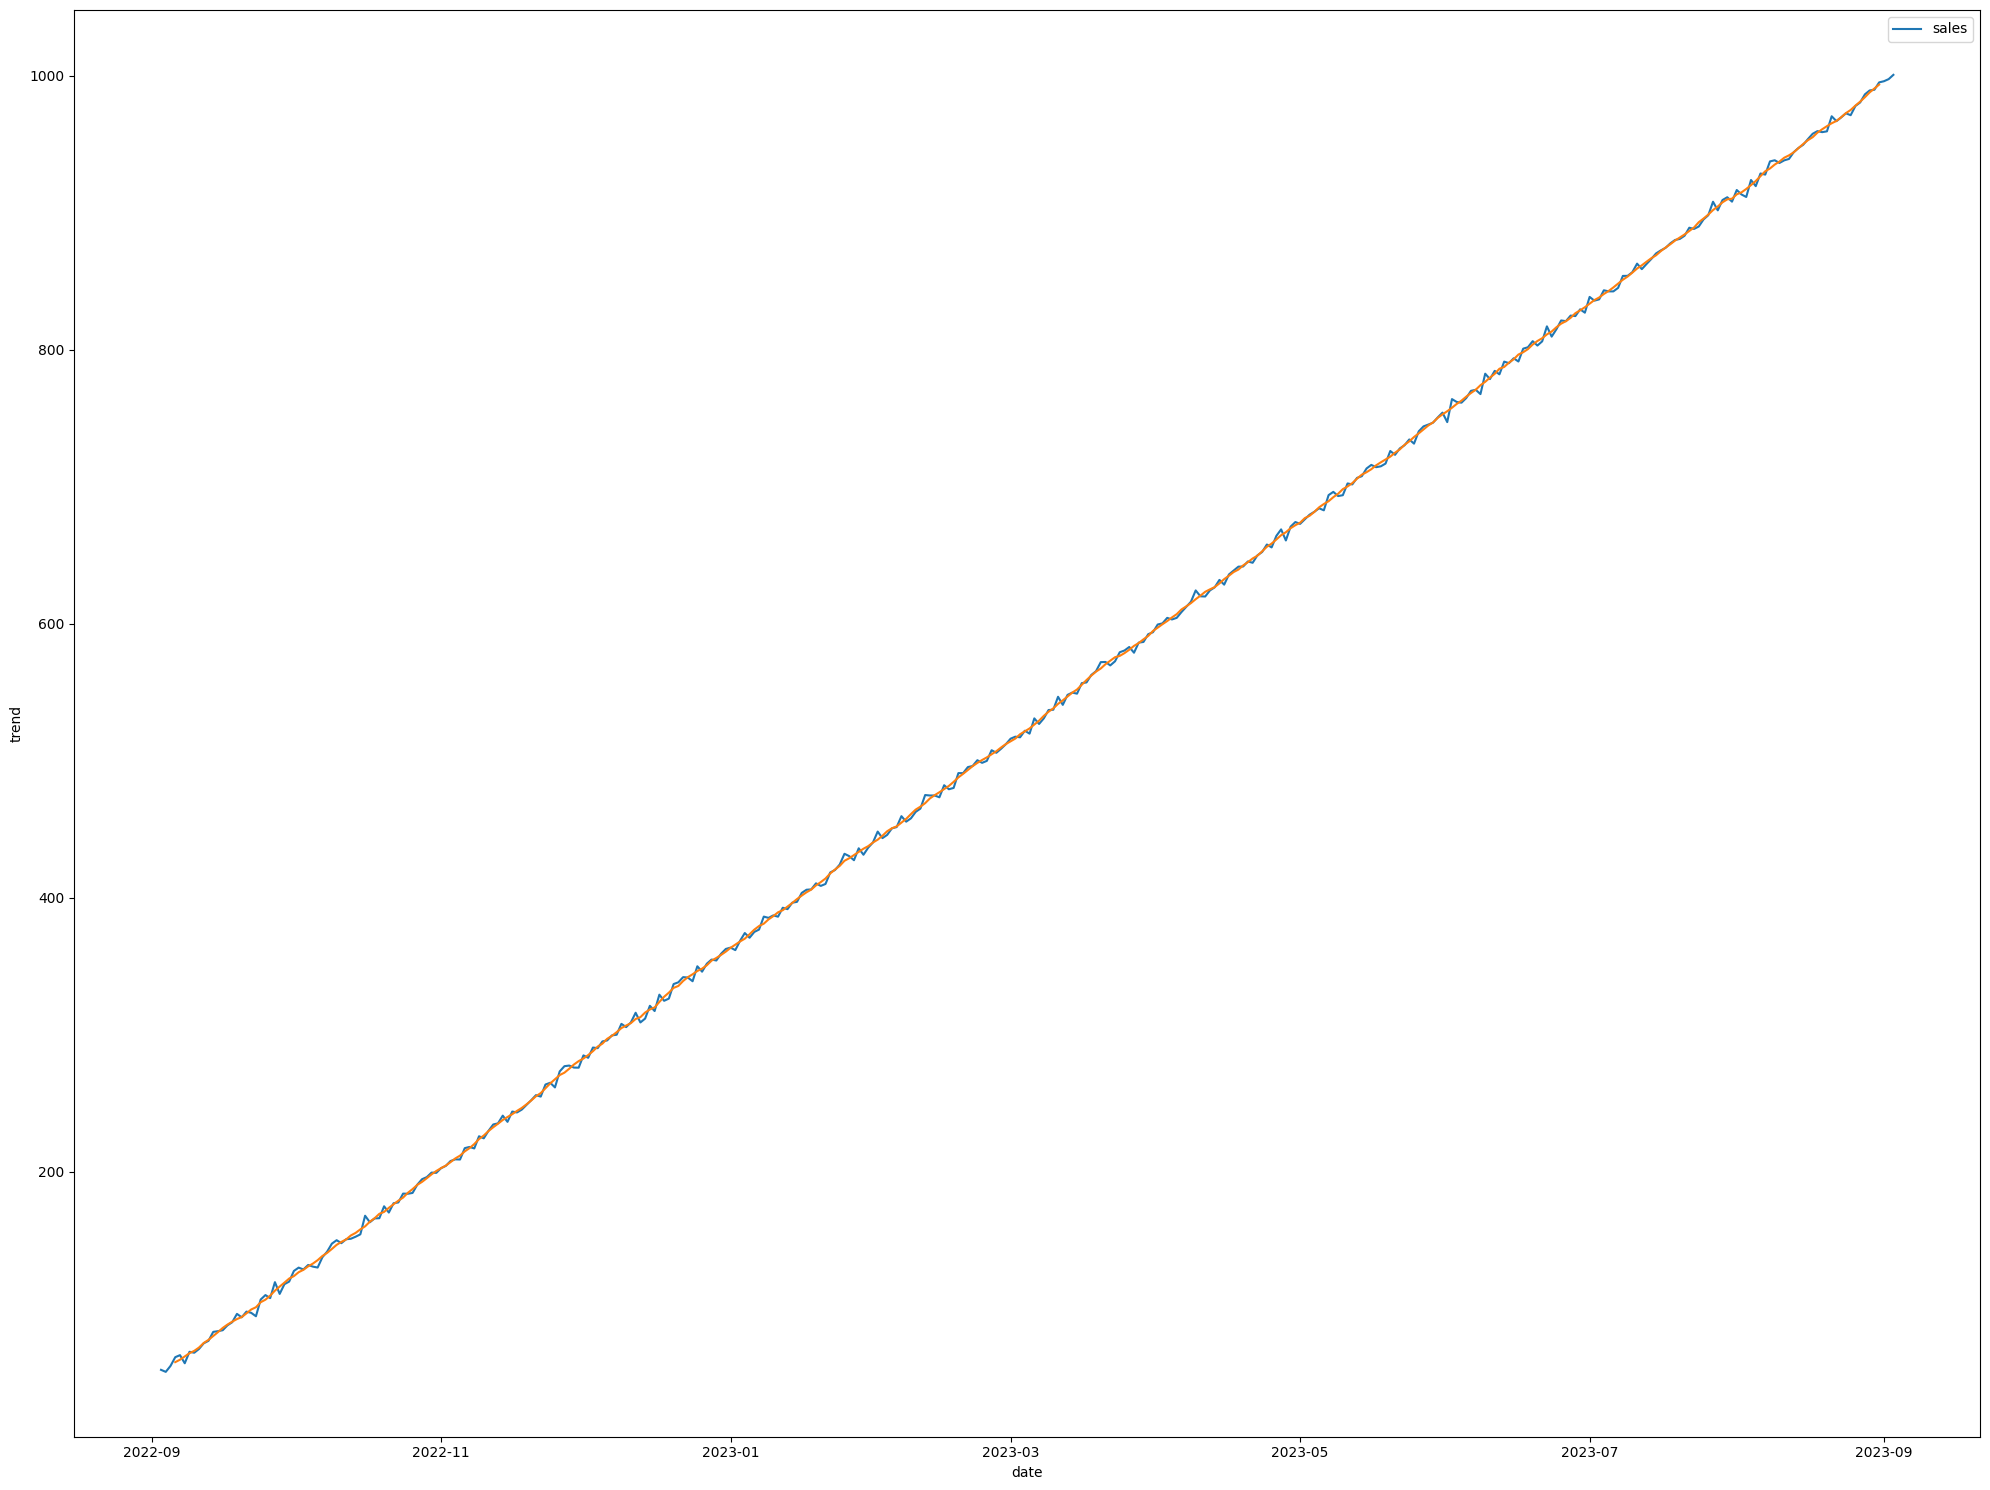

In [15]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (20, 15))

sns.lineplot(data = df)
sns.lineplot(data = trend)

plt.tight_layout()

> ## Conclusiones:
>
> - Se confirma lo observado, una clara tendencia positiva de las ventas a los largo del año

## ¿Es estacionaria?

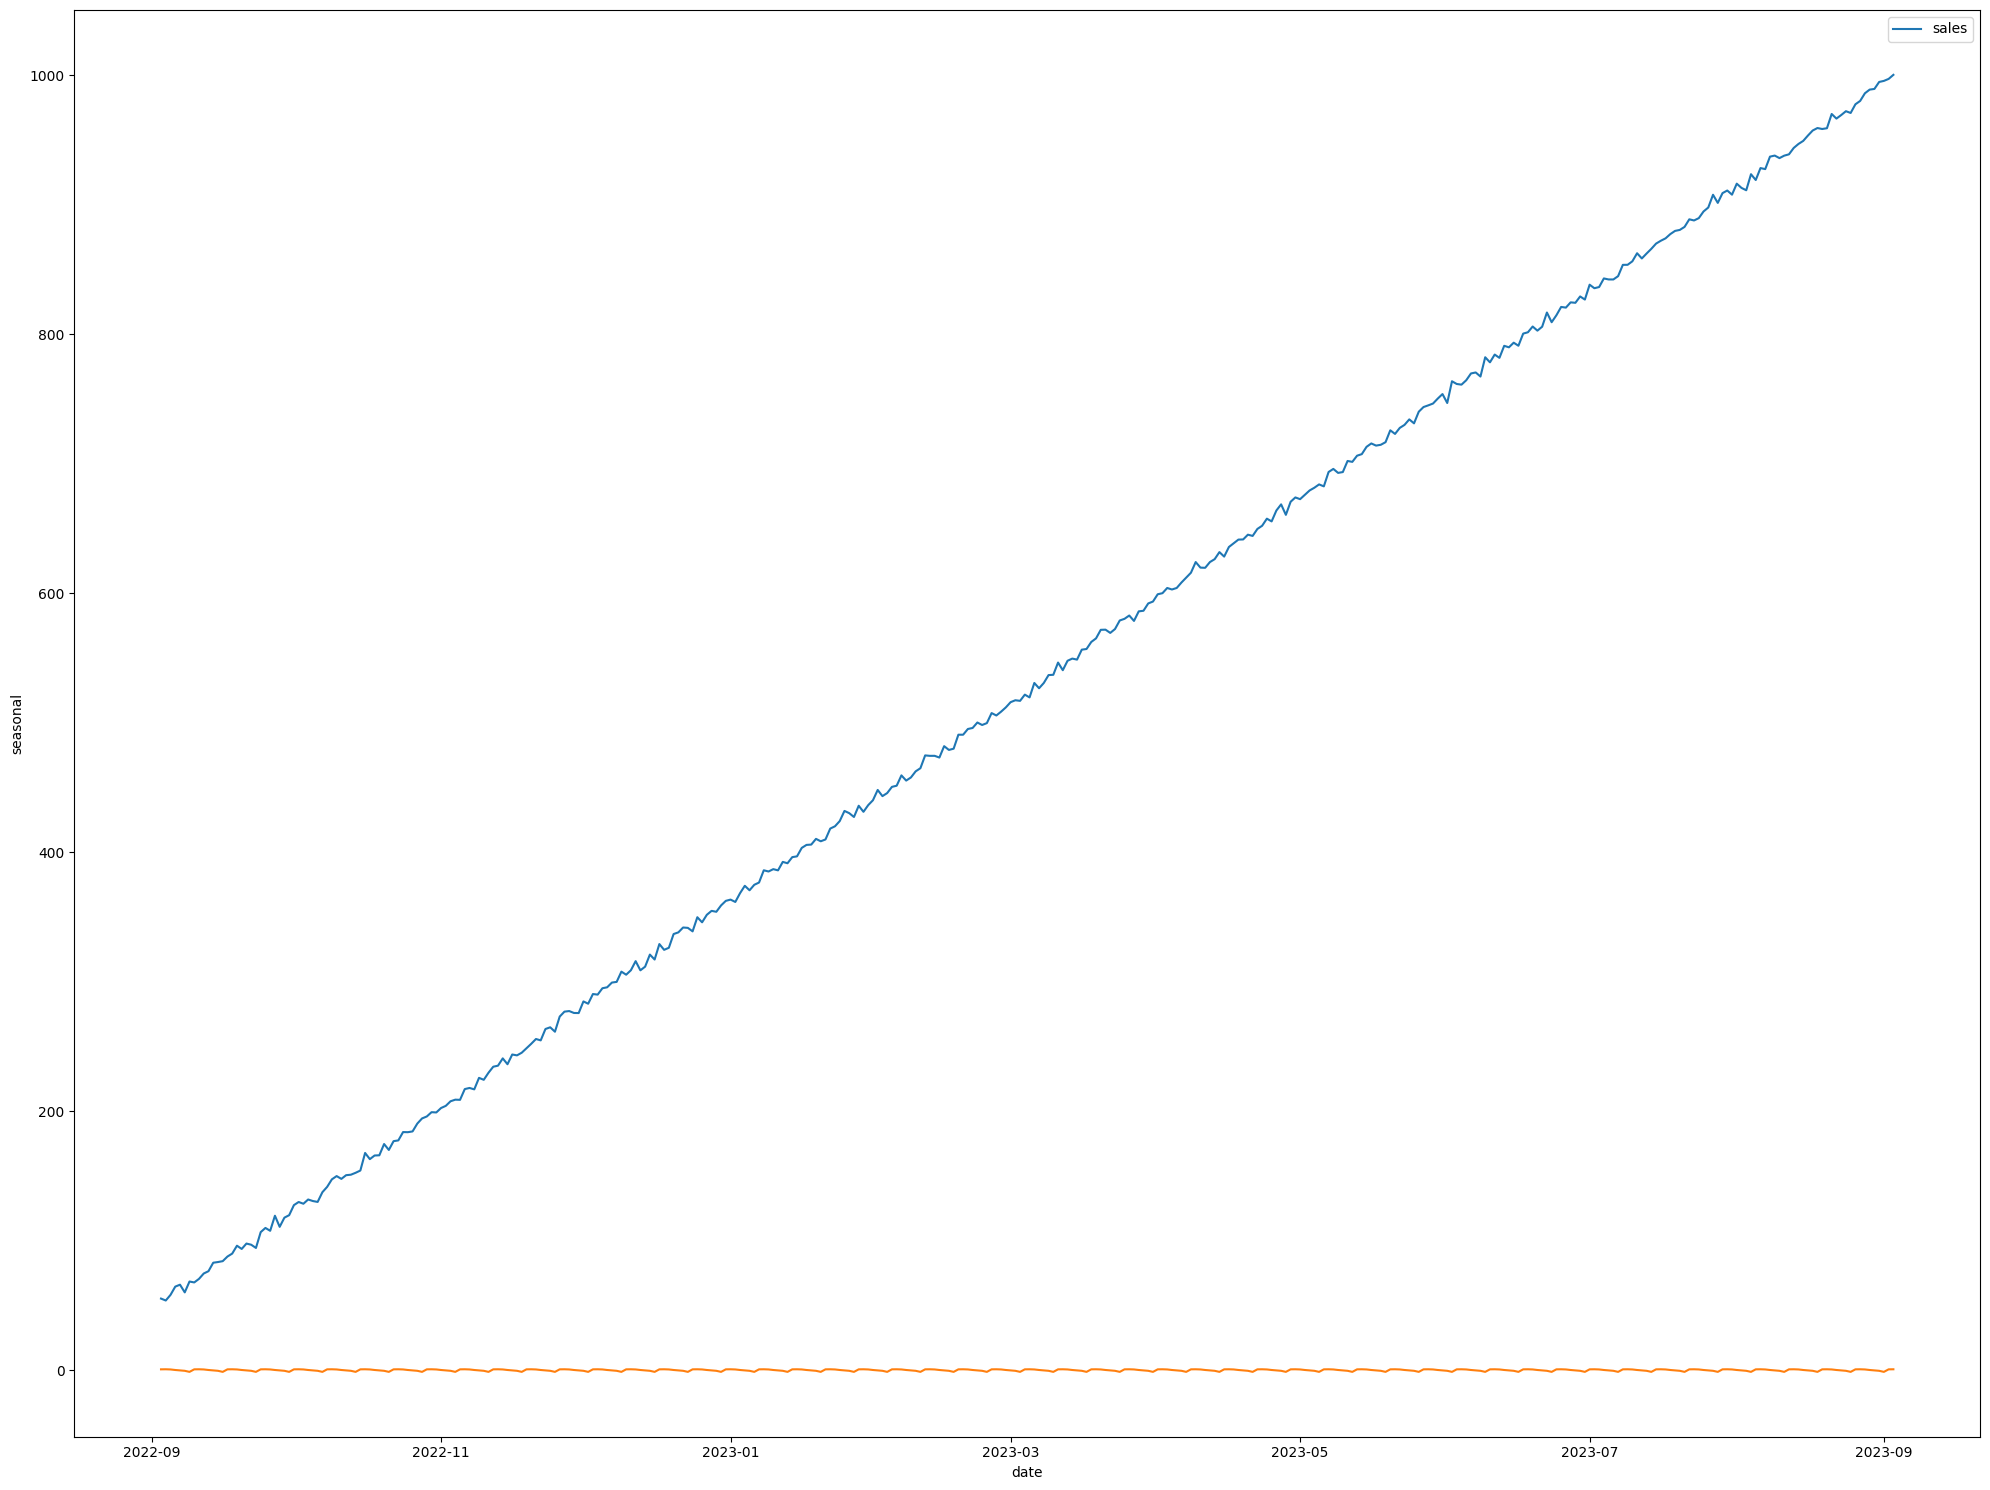

In [16]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (20, 15))

sns.lineplot(data = df)
sns.lineplot(data = seasonal)

plt.tight_layout()

In [17]:
test_stationarity(df)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

> ## Conclusiones:
>
> - El p-value es mucho mayor que 0.05, esto significa que no podemos rechazar la hipostesis nula por lo que tomaremos esta serie como no estacionaria
> - Para poder usar el modelos ARIMA, necesitamos hacer que la serie sea estacionaria

## ¿Existe variabilidad o presencia de ruido?

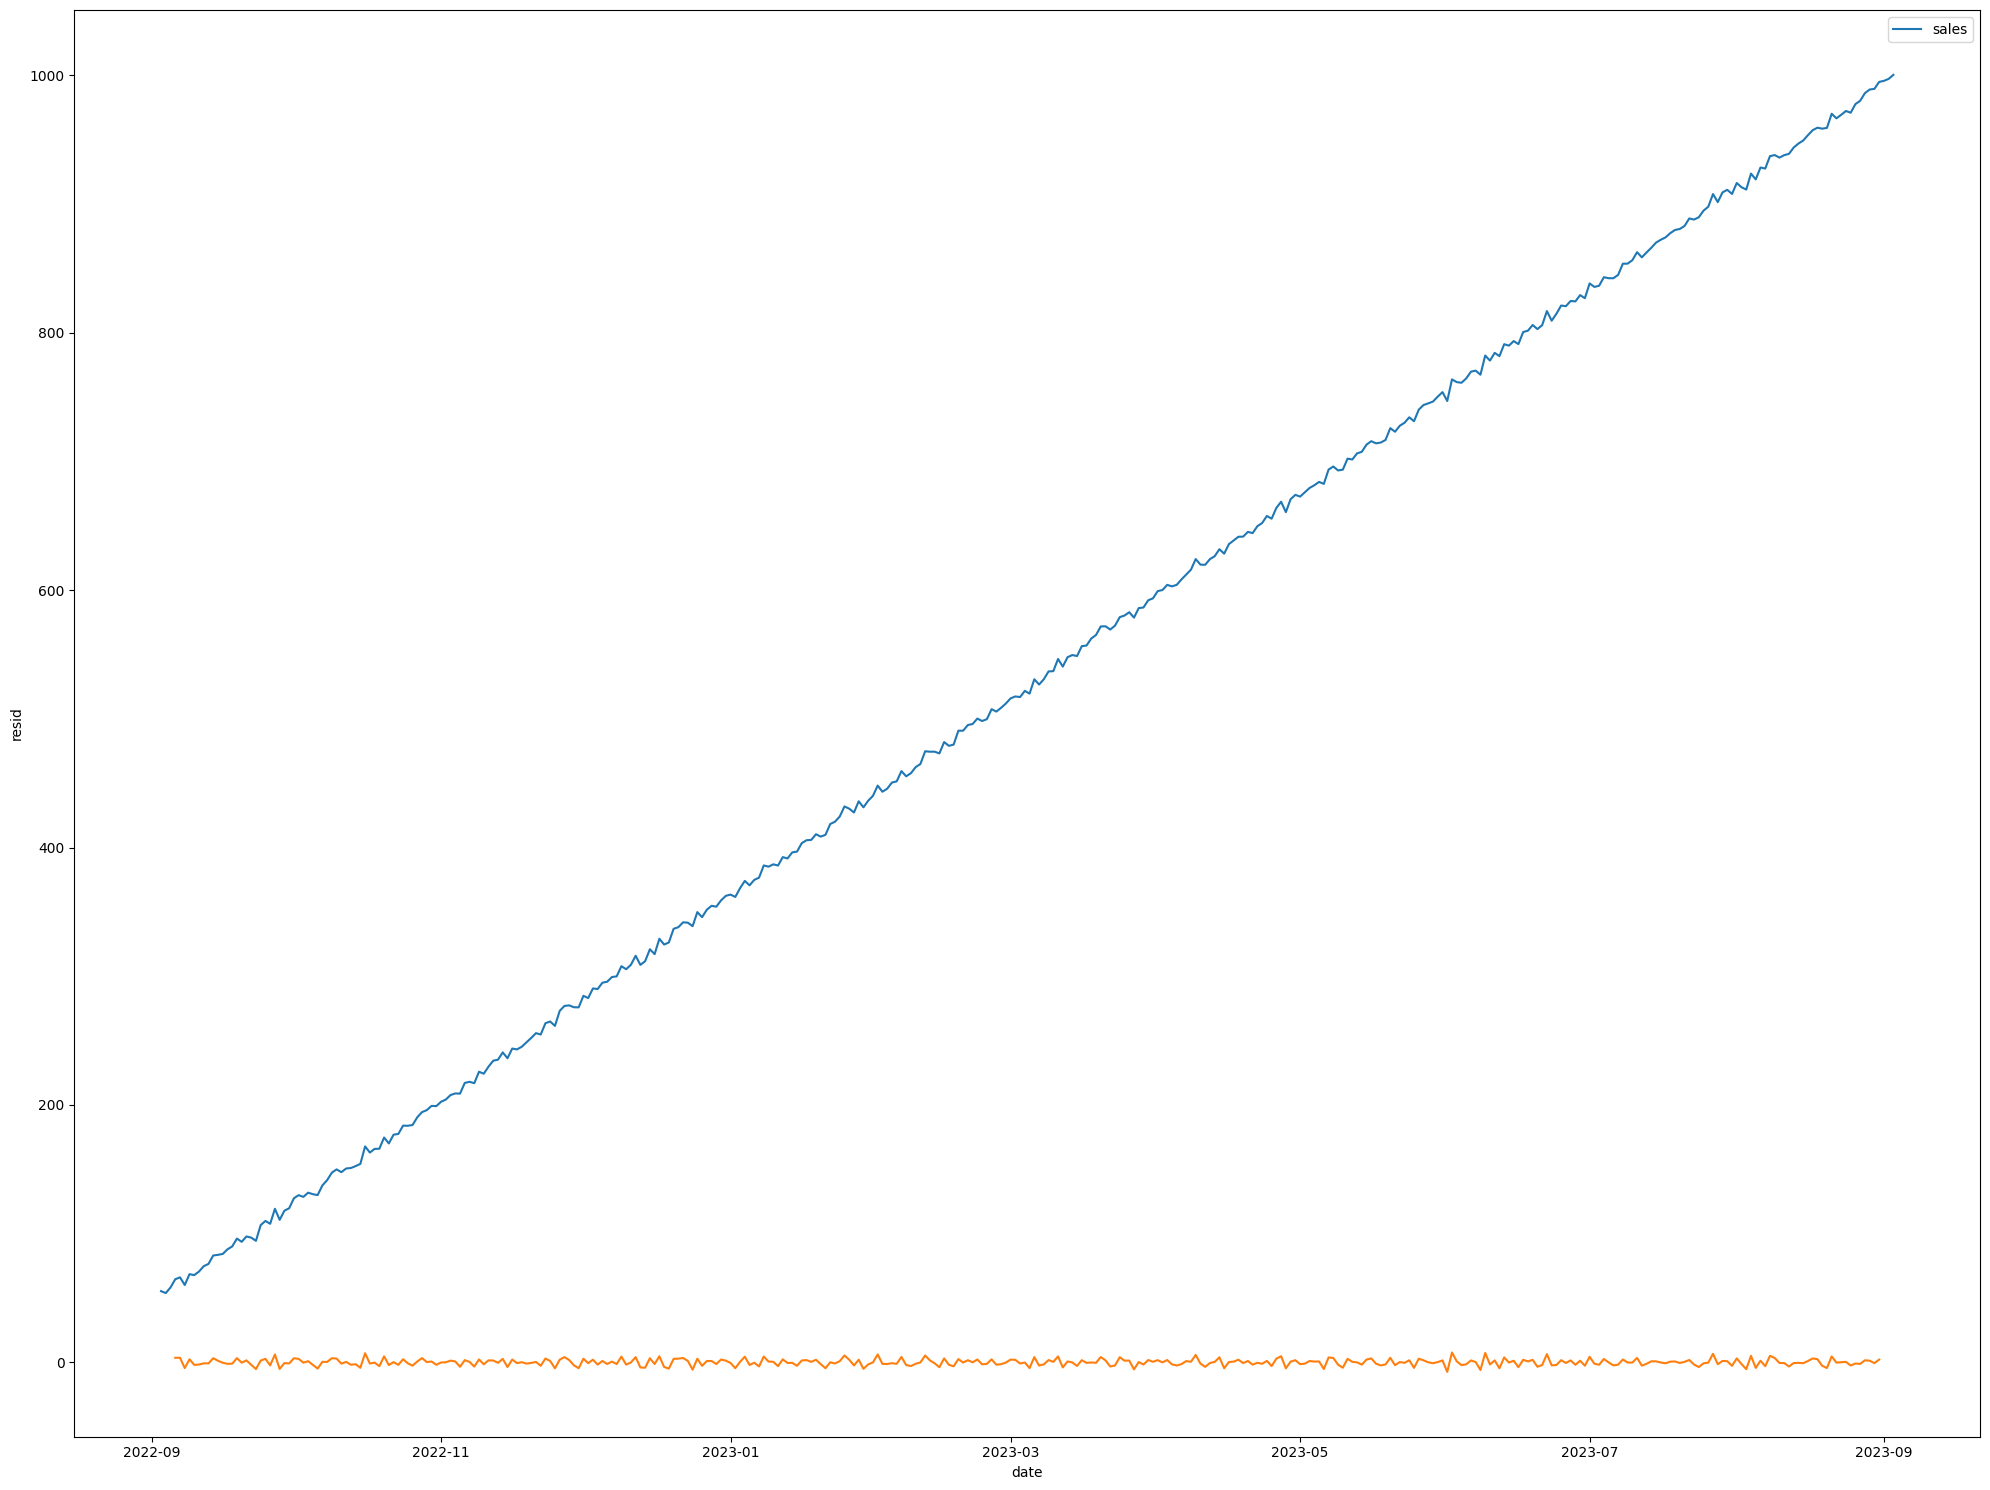

In [18]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (20, 15))

sns.lineplot(data = df)
sns.lineplot(data = residual)

plt.tight_layout()

> ## Conclusiones:
>
> - No se aprecia mucho ruido considerable

# Paso 4: Entrenamos y predecimos con ARIMA (sin split)

In [ ]:
# Lo primero tenemos que transformar la serie en estacionaria
df_stationary = df.diff().dropna()

test_stationarity(df_stationary)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

> ## Conclusiones:
>
> - Ahora la serie si que es estacionaria (p-value < 0.05), por lo que podemos aplicar el método ARIMA automático

In [33]:
model = auto_arima(df_stationary, seasonal=True, trace=True, m=7)


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.43 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=2096.542, Time=0.03 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=1966.396, Time=0.24 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=inf, Time=1.15 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,0,2)(0,0,1)[7] intercept   : AIC=1861.509, Time=1.18 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,1)(0,0,1)[7]             : AIC=inf, Time=0.78 sec

Best model:  ARIMA(3,0,1)(0,0,1)[7] intercept
Total fit time: 51.151 seconds


In [34]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  365
Model:             SARIMAX(3, 0, 1)x(0, 0, 1, 7)   Log Likelihood                -911.892
Date:                           Sun, 20 Jul 2025   AIC                           1837.785
Time:                                   07:31:30   BIC                           1865.084
Sample:                               09-04-2022   HQIC                          1848.634
                                    - 09-03-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.2873      0.259      8.827      0.000       1.779       2.795
ar.L1         -0.0458      0.053     -0.868      0.386      -0.149       0.058
ar.L2          0.0793      0.057      1.379      0.168      -0.033       0.192
ar.L3          0.0868      0.054      1.617      0.106      -0.018       0.192
ma.L1         -0.9897      0.022    -44.347      0.000      -1.033      -0.946
ma.S.L7        0.1250      0.053      2.350      0.019       0.021       0.229
sigma2         8.5685      0.674     12.705      0.000       7.247       9.890
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.63
Prob(Q):                              0.93   Prob(JB):                         0.73
Heteroskedasticity (H):               0.86   Skew:                             0.06
Prob(H) (two-sided):                  0.40   Kurtosis:                         2.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
forecast = model.predict(30)
forecast

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


2023-09-04    2.015222
2023-09-05    2.661789
2023-09-06    2.318595
2023-09-07    2.866267
2023-09-08    2.435838
2023-09-09    2.388433
2023-09-10    2.655394
2023-09-11    2.490794
2023-09-12    2.590925
2023-09-13    2.596447
2023-09-14    2.589852
2023-09-15    2.599280
2023-09-16    2.598804
2023-09-17    2.599001
2023-09-18    2.599772
2023-09-19    2.599711
2023-09-20    2.599792
2023-09-21    2.599851
2023-09-22    2.599849
2023-09-23    2.599861
2023-09-24    2.599865
2023-09-25    2.599866
2023-09-26    2.599867
2023-09-27    2.599868
2023-09-28    2.599868
2023-09-29    2.599868
2023-09-30    2.599868
2023-10-01    2.599868
2023-10-02    2.599868
2023-10-03    2.599868
Freq: D, dtype: float64

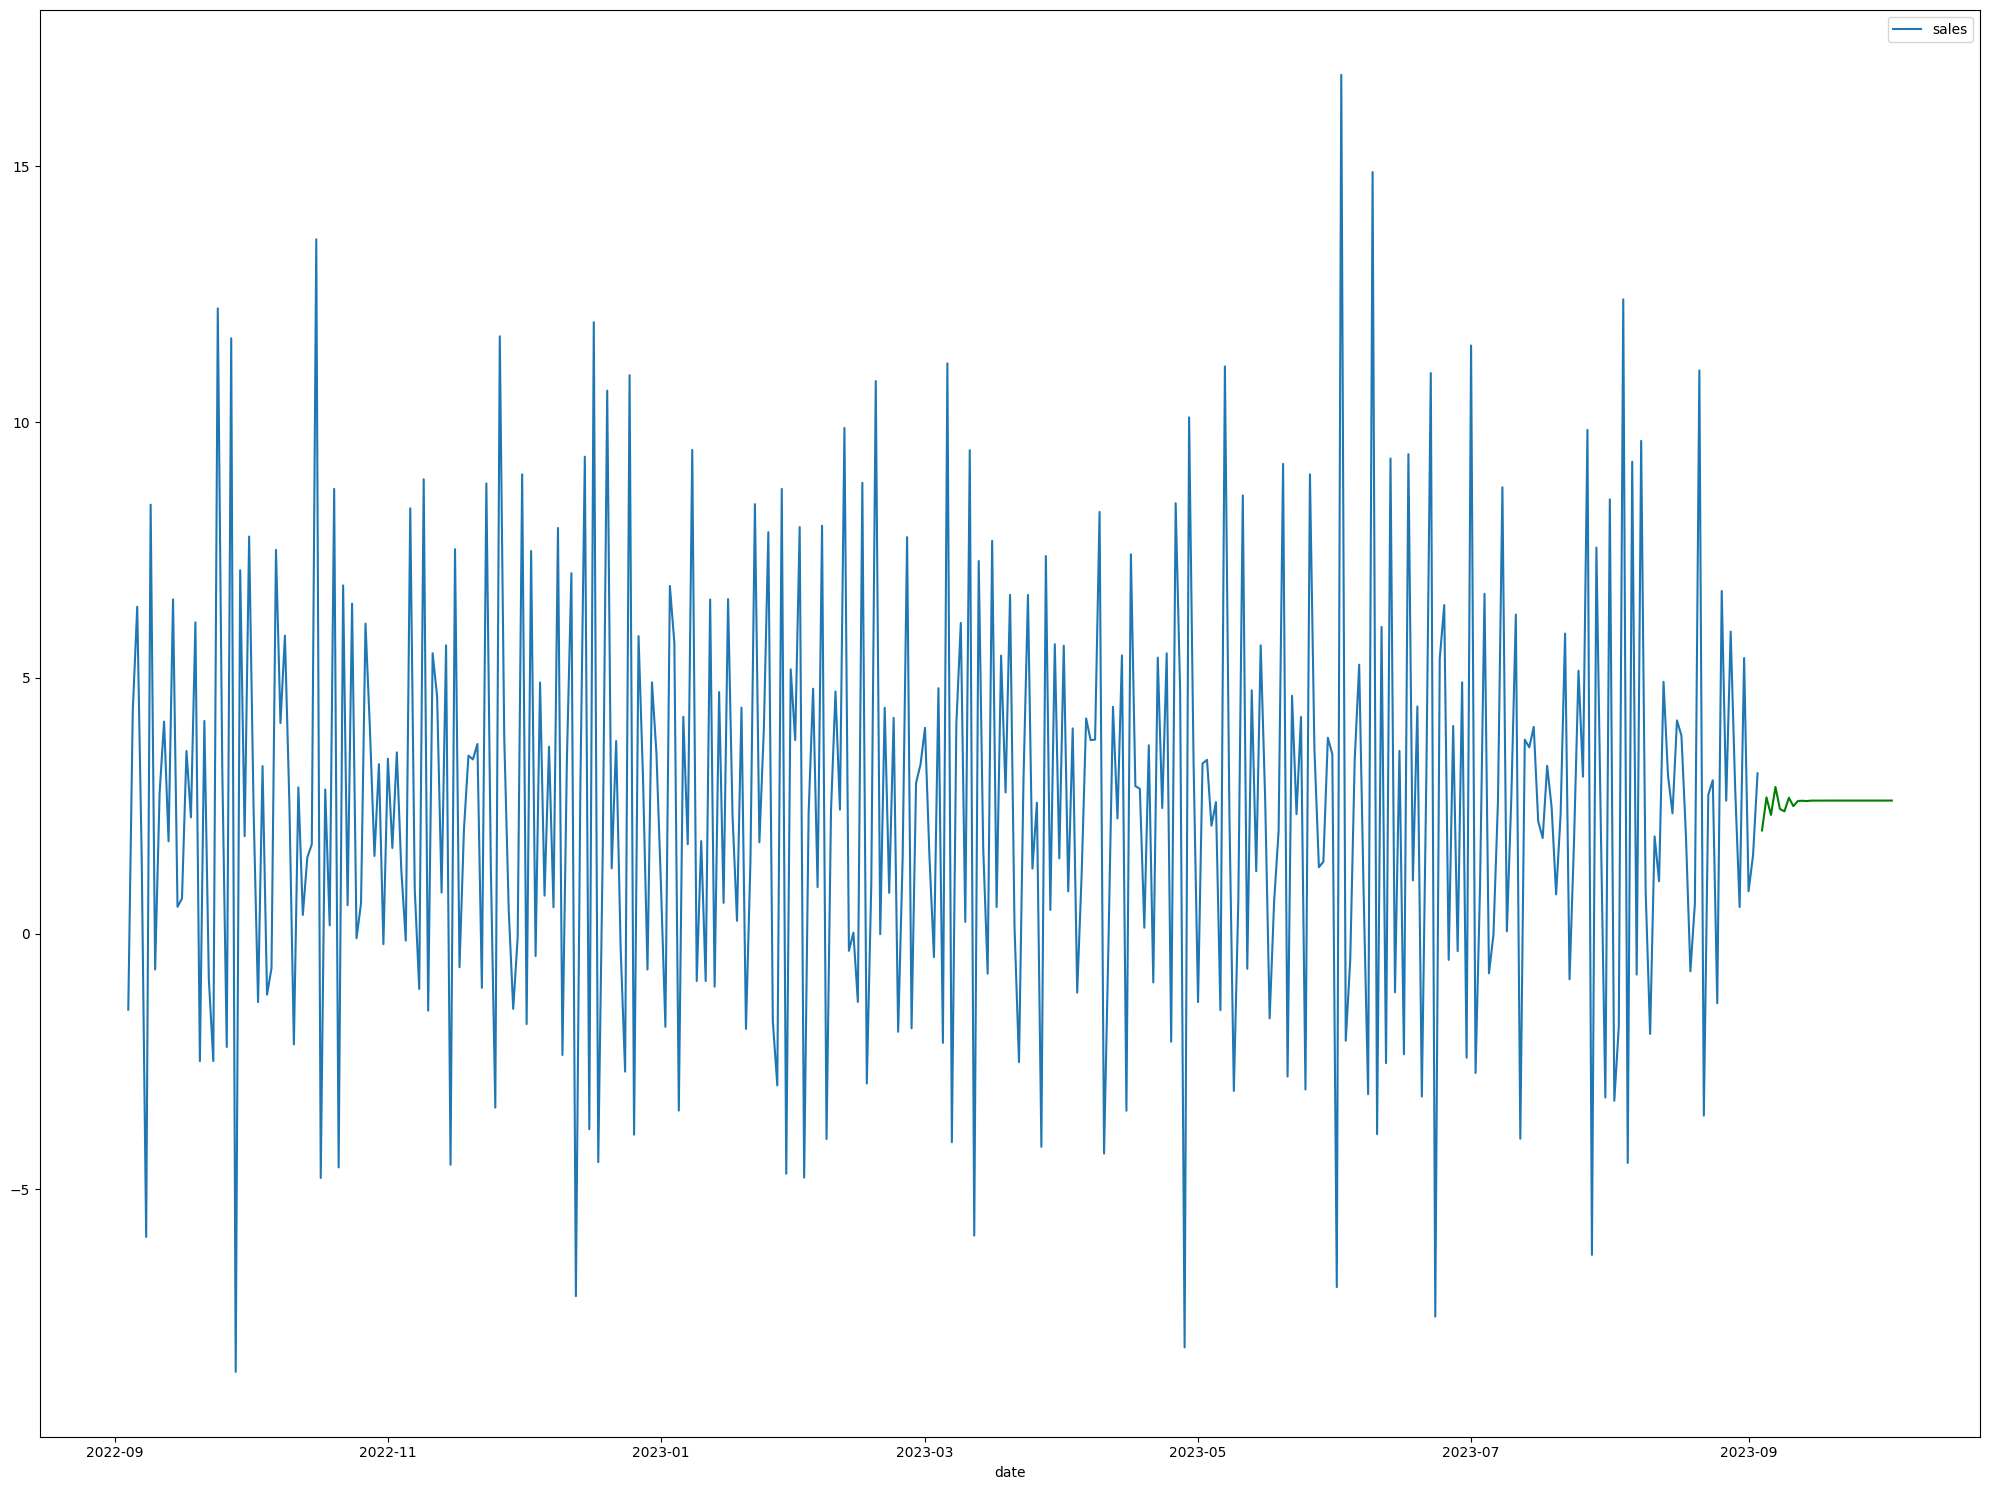

In [ ]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (20, 15))

sns.lineplot(data = df_stationary)
sns.lineplot(data = forecast, c = "green")

plt.ylabel("Sales")
plt.title("Pronóstico de cambios diarios en ventas con ARIMA (serie diferenciada)")

plt.tight_layout()

In [43]:
df

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633
...,...
2023-08-30,989.600354
2023-08-31,994.987326
2023-09-01,995.814415


In [74]:
# Reconstruimos la predición en la escala original

# Ultimo valor real conocido antes del forecast
last_real_value = df["sales"].iloc[-1]

# Sumar acumulativamente las predicciones (cambios diarios) al último valor real
forecast_original_scale = forecast.cumsum() + last_real_value

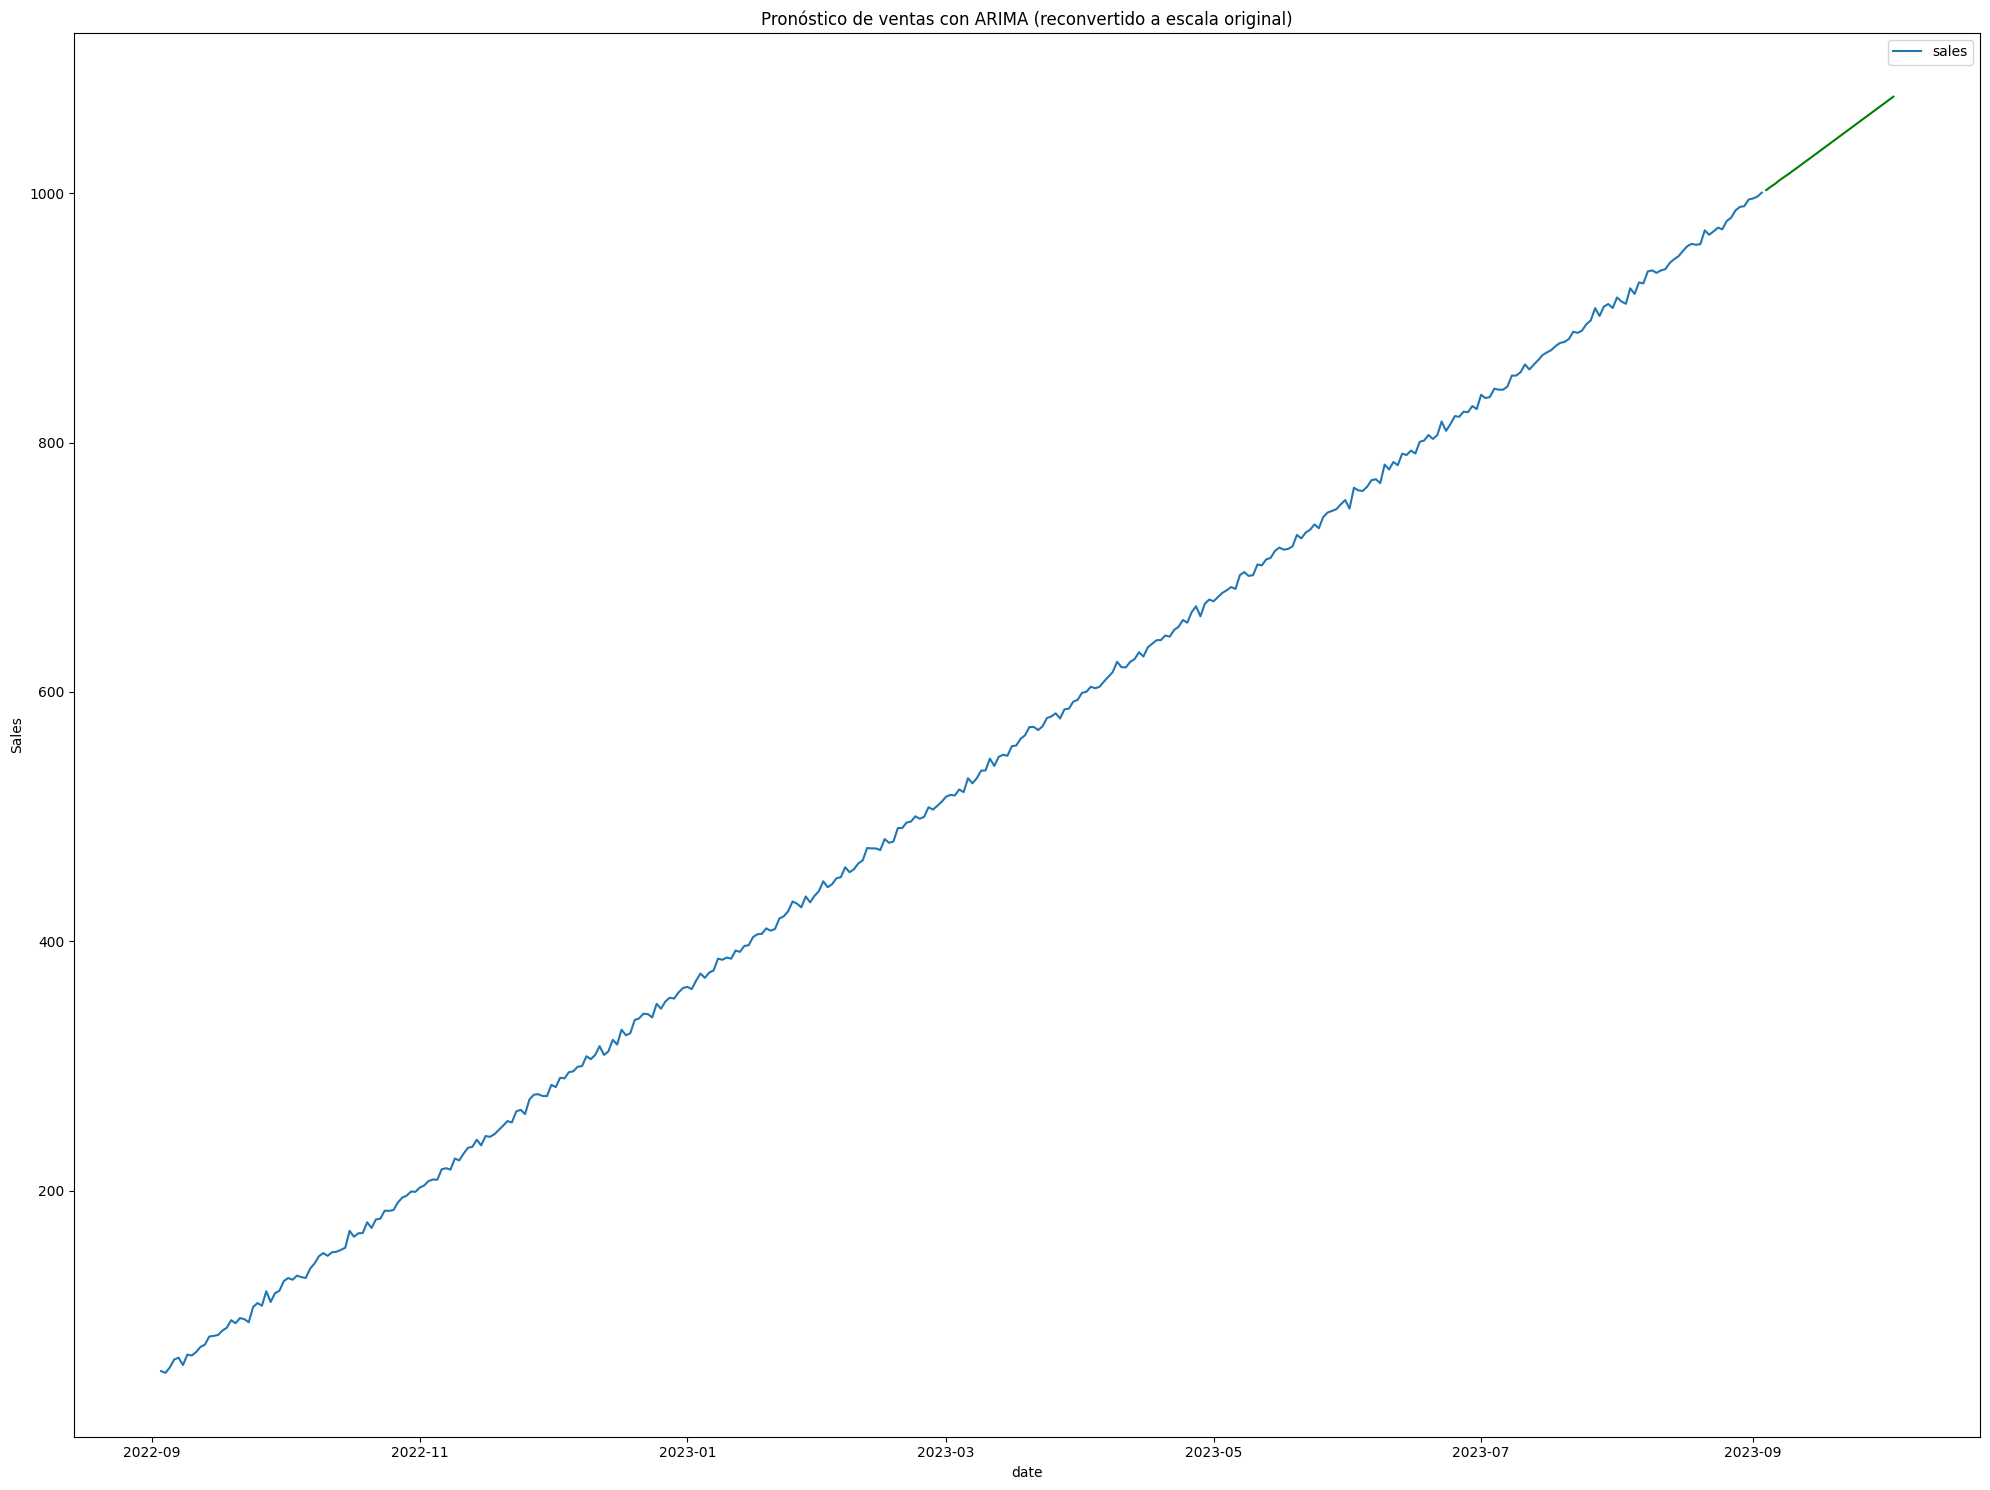

In [48]:
fig, axis = plt.subplots(figsize = (20, 15))

sns.lineplot(data = df)
sns.lineplot(data = forecast_original_scale, c = "green")

plt.ylabel("Sales")
plt.title("Pronóstico de ventas con ARIMA (reconvertido a escala original)")

plt.tight_layout()

# Paso 4: Entrenamos y predecimos con ARIMA (con split)

In [66]:
# Split: 30 días finales como test
train = df.iloc[:-30]
test = df.iloc[-30:]

test

,sales
date,
2023-08-05,919.252876
2023-08-06,928.476091
2023-08-07,927.673995
2023-08-08,937.307420
2023-08-09,938.137035
2023-08-10,936.174089
2023-08-11,938.073473
2023-08-12,939.097494
2023-08-13,944.019698


In [67]:
# Calculamos las diferencias con el conjunto de entrenamiento y comprobamos que es estacionaria
df_dif = train.diff().dropna()
test_stationarity(df_dif)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -8.670863e+00
p-value                        4.550432e-14
#Lags Used                     1.200000e+01
Number of Observations Used    3.220000e+02
Critical Value (1%)           -3.450823e+00
Critical Value (5%)           -2.870558e+00
Critical Value (10%)          -2.571575e+00
dtype: float64

In [68]:
arima_model = auto_arima(df_dif, seasonal=True, trace=True, m=7)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=1698.828, Time=0.90 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=1933.617, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=1816.473, Time=0.10 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=2035.035, Time=0.01 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(1,0,2)(1,0,0)[7] intercept   : AIC=inf, Time=0.77 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=1931.167, Time=0.06 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,2)(1,0,0)[7] intercept   : AIC=1691.516, Time=0.37 sec
 ARIMA(2,0,0)(1,0,0)[7] intercept   : AIC=1766.236, Time=0.16 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(1,0,0)[7]             : AIC=inf, Time=0.50 sec

Best model:  ARIMA(1,0,1)(1,0,0)[7] intercept
Total fit time: 28.163 seconds


In [86]:
# Predecimos los cambios diarios para los próximos 30 día
forecast_arima = arima_model.predict(30)
forecast_arima

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


2023-08-05    0.427363
2023-08-06    2.741124
2023-08-07    1.704645
2023-08-08    3.486209
2023-08-09    1.713456
2023-08-10    1.931329
2023-08-11    4.073712
2023-08-12    2.270325
2023-08-13    2.618860
2023-08-14    2.462729
2023-08-15    2.731096
2023-08-16    2.464056
2023-08-17    2.496876
2023-08-18    2.819595
2023-08-19    2.547941
2023-08-20    2.600443
2023-08-21    2.576924
2023-08-22    2.617349
2023-08-23    2.577124
2023-08-24    2.582067
2023-08-25    2.630680
2023-08-26    2.589760
2023-08-27    2.597668
2023-08-28    2.594125
2023-08-29    2.600215
2023-08-30    2.594156
2023-08-31    2.594900
2023-09-01    2.602223
2023-09-02    2.596059
2023-09-03    2.597250
Freq: D, dtype: float64

In [80]:
last_real_value_2 = train.iloc[-1]
last_real_value_2

sales    923.736767
Name: 2023-08-04, dtype: float64

In [ ]:
# Recuperamos la escala original

# Ultimo valor real conocido antes del forecast
last_real_value_2 = train["sales"].iloc[-1]

# Sumar acumulativamente las predicciones de las difrencias al ultimo valor real
forecast_original_scale_2 = forecast_arima.cumsum() + last_real_value_2

forecast_original_scale_2.index = test.index

forecast_original_scale_2, test

(date
 2023-08-05    924.164130
 2023-08-06    926.905254
 2023-08-07    928.609899
 2023-08-08    932.096108
 2023-08-09    933.809564
 2023-08-10    935.740893
 2023-08-11    939.814605
 2023-08-12    942.084930
 2023-08-13    944.703790
 2023-08-14    947.166519
 2023-08-15    949.897615
 2023-08-16    952.361672
 2023-08-17    954.858547
 2023-08-18    957.678142
 2023-08-19    960.226083
 2023-08-20    962.826526
 2023-08-21    965.403450
 2023-08-22    968.020799
 2023-08-23    970.597922
 2023-08-24    973.179990
 2023-08-25    975.810670
 2023-08-26    978.400430
 2023-08-27    980.998098
 2023-08-28    983.592224
 2023-08-29    986.192439
 2023-08-30    988.786594
 2023-08-31    991.381494
 2023-09-01    993.983718
 2023-09-02    996.579777
 2023-09-03    999.177027
 dtype: float64,
                   sales
 date                   
 2023-08-05   919.252876
 2023-08-06   928.476091
 2023-08-07   927.673995
 2023-08-08   937.307420
 2023-08-09   938.137035
 2023-08-10   936.1740

In [106]:
metrics = {"MAE": mean_absolute_error(test, forecast_original_scale_2),
           "MSE": mean_squared_error(test, forecast_original_scale_2),
           "RMSE": np.sqrt(mean_squared_error(test, forecast_original_scale_2))}
metrics

{'MAE': 2.0713604116355477, 'MSE': 6.6152277711664, 'RMSE': 2.5720085091551312}

In [121]:
forecast_original_scale_2

date
2023-08-05    924.164130
2023-08-06    926.905254
2023-08-07    928.609899
2023-08-08    932.096108
2023-08-09    933.809564
2023-08-10    935.740893
2023-08-11    939.814605
2023-08-12    942.084930
2023-08-13    944.703790
2023-08-14    947.166519
2023-08-15    949.897615
2023-08-16    952.361672
2023-08-17    954.858547
2023-08-18    957.678142
2023-08-19    960.226083
2023-08-20    962.826526
2023-08-21    965.403450
2023-08-22    968.020799
2023-08-23    970.597922
2023-08-24    973.179990
2023-08-25    975.810670
2023-08-26    978.400430
2023-08-27    980.998098
2023-08-28    983.592224
2023-08-29    986.192439
2023-08-30    988.786594
2023-08-31    991.381494
2023-09-01    993.983718
2023-09-02    996.579777
2023-09-03    999.177027
dtype: float64

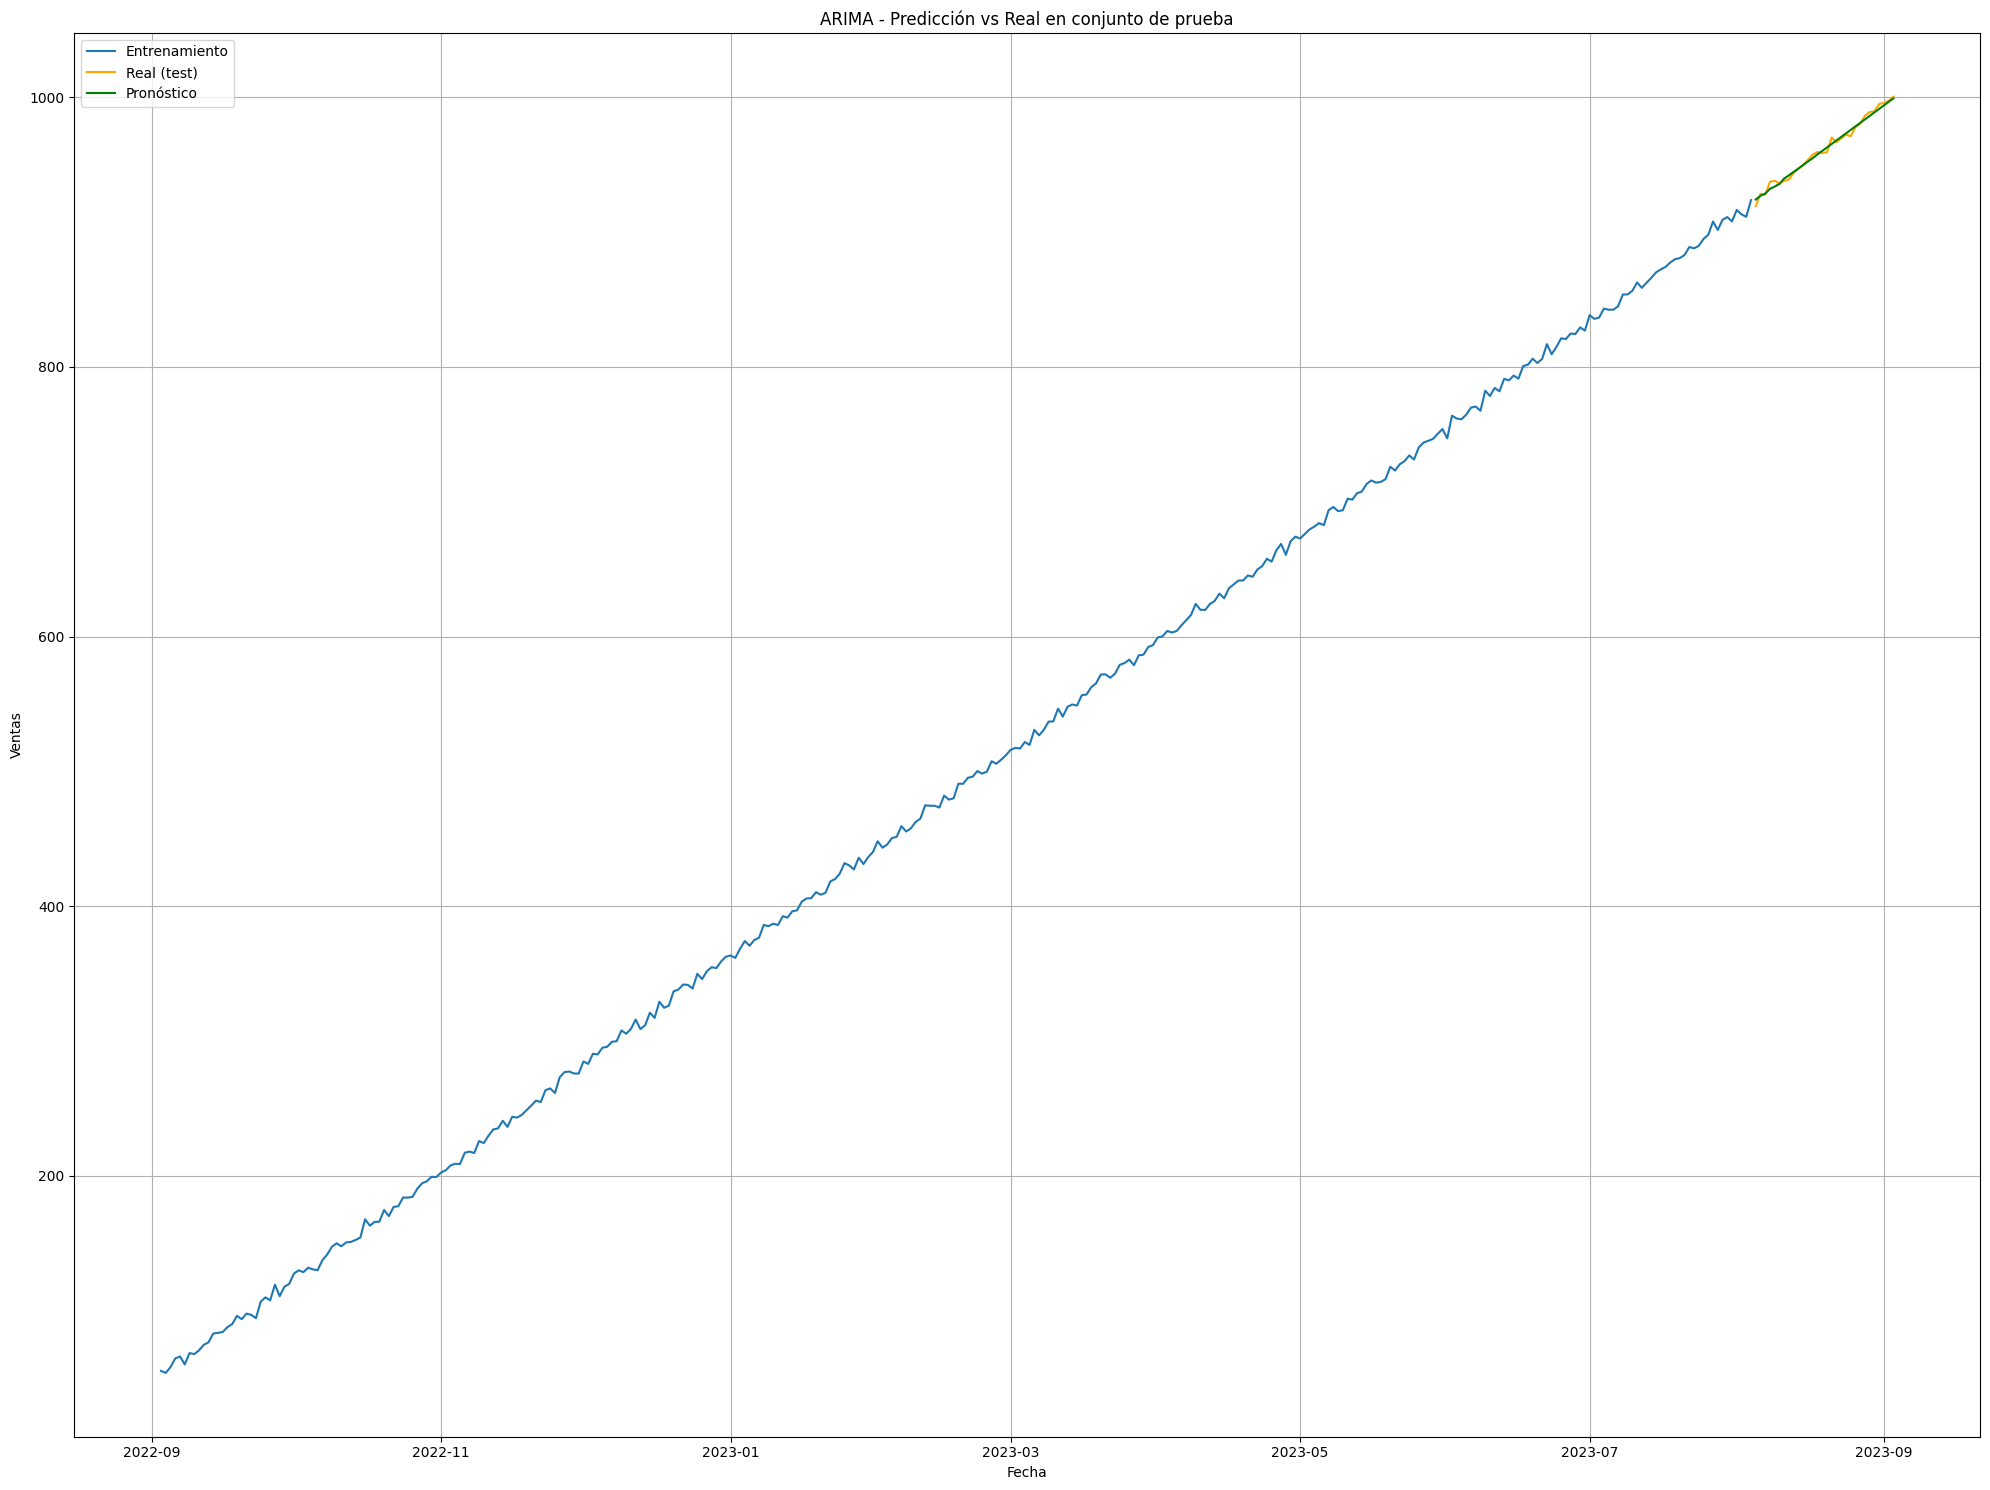

In [122]:
plt.figure(figsize=(20, 15))

# Entrenamiento
sns.lineplot(x=train.index, y=train["sales"], label="Entrenamiento")

# Test real
sns.lineplot(x=test.index, y=test["sales"], label="Real (test)", color="orange")

# Predicción
sns.lineplot(x=forecast_original_scale_2.index, y=forecast_original_scale_2, label="Pronóstico", color="green")

plt.title("ARIMA - Predicción vs Real en conjunto de prueba")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.legend()